> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib pandas


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

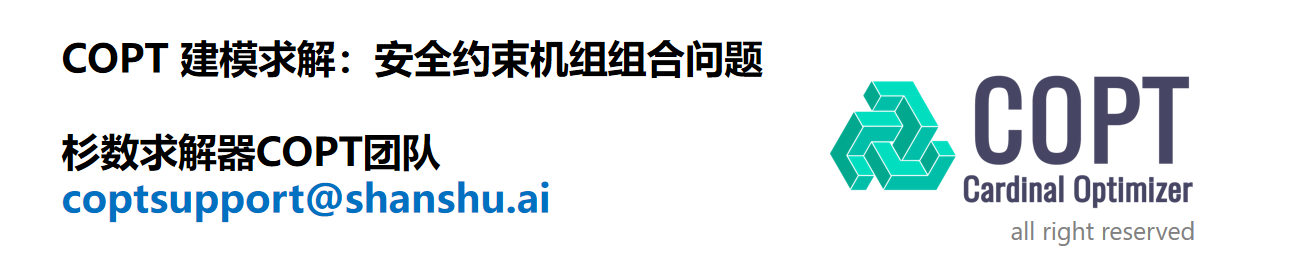

# 安全约束机组组合问题代码实现
## 使用COPT建模求解安全机组组合问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入数据**
    - 导入参数列表（包括发电机种类，相关参数以及客户需求等）

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：
        - $\text{num\_gen}_{t,p} \in \mathbb{N}^+$：在时间段 $p$ 中，处于运行状态的机组$t$的数量。（台）
        - $\text{output}_{t,p} \in \mathbb{R}^+$：在时间段 $p$ 中，类型为$t$的机组总功率输出。（兆瓦）
        - $\text{num\_start}_{t,p} \in \mathbb{N}^+$：在时间段 $p$ 中，开机的机组$t$的数量。（台）
        - $\text{num\_stop}_{t,p} \in \mathbb{N}^+$：在时间段 $p$ 中，关机的机组$t$的数量。（台）
    - **目标函数**：最小化三部分的总费用；
    - **约束条件**：
        - **满足发电机可用数量上限**
        - **满足需求**
        - **最小/最大发电量**
        - **储备**
        - **开关机数量守恒**
        - **爬坡速率约束**
        - **最小启停时间**

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

import pandas as pd

import matplotlib.pyplot as plt


## 添加模型数据

In [6]:
# 导入发电机种类数量
num_types = 4
# 导入时间段数量
num_periods = 7
# 导入第一个时间段开始前已经处于运行状态的各发电机数量
start0 = [2, 3, 1, 4]
# 添加爬坡速率rampup
Rampup = [800, 400, 1500, 600]
# 添加不同时间段内小时数量
period_hours = [6, 2, 2, 3, 5, 4, 2]
# 添加不同型号发电机数量
generators = [20, 15, 8, 12]
# 添加不同时间段需求数量
demand = [25000, 45000, 49000, 55000, 48000, 62000, 30000]
# 添加发电机最低发电功率
min_load = [600, 900, 1200, 800]
# 添加发电机最高发电功率
max_load = [1500, 2200, 5000, 1800]
# 添加最低运行成本
base_cost = [1800, 3000, 4500, 2000]
# 添加超额成本
run_over_cost = [1.8, 1.5, 3.5, 2.2]
# 添加开机成本
start_up_cost = [3000, 1500, 800, 2500]


## 创建求解环境和求解模型

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素
### 添加决策变量
- $\text{num\_gen}_{t,p} \in \mathbb{N}^+$：在时间段 $p$ 中，处于运行状态的机组$t$的数量。（台）
- $\text{output}_{t,p} \in \mathbb{R}^+$：在时间段 $p$ 中，类型为$t$的机组总功率输出。（兆瓦）
- $\text{num\_start}_{t,p} \in \mathbb{N}^+$：在时间段 $p$ 中，开机的机组$t$的数量。（台）
- $\text{num\_stop}_{t,p} \in \mathbb{N}^+$：在时间段 $p$ 中，关机的机组$t$的数量。（台）


In [10]:
num_gen = model.addVars(num_types, num_periods, vtype=COPT.INTEGER, nameprefix="num_gen")
num_start = model.addVars(num_types, num_periods, vtype=COPT.INTEGER, nameprefix="num_start")
num_stop = model.addVars(num_types, num_periods, vtype=COPT.INTEGER, nameprefix="num_stop")
output = model.addVars(num_types, num_periods, vtype=COPT.CONTINUOUS, nameprefix="output")


### 设置目标函数
**最小化总成本**：在满足各时间段供电需求的同时，最小化总发电成本。

**总成本构成**：运行成本 + 超额成本 + 开机成本

$$
\begin{equation}
    \text{Minimize} \quad Z_{on} + Z_{extra} + Z_{startup}
\end{equation}
$$

- 运行成本：
$$
\begin{equation}
    Z_{on} = \sum_{(t,p) \in \text{Types} \times \text{Periods}}{\text{period\_hours}_p*\text{base\_cost}_t*\text{num\_gen}_{t,p}}
\end{equation}
$$

- 超额发电成本：
$$
\begin{equation}
    Z_{extra} = \sum_{(t,p) \in \text{Types} \times \text{Periods}}{\text{per\_mw\_cost}_t*(\text{output}_{t,p} - \text{min\_load}_t)}
\end{equation}
$$

- 开机成本：
$$
\begin{equation}
    Z_{startup} = \sum_{(t,p) \in \text{Types} \times \text{Periods}}{\text{startup\_cost}_t*\text{num\_start}_{t,p}}
\end{equation}
$$

In [12]:
active = cp.quicksum(base_cost[type]*period_hours[period]*num_gen[type,period]
                    for type in range(num_types) for period in range(num_periods))

per_mw = cp.quicksum(run_over_cost[type]*period_hours[period]*(output[type,period] - min_load[type]*num_gen[type,period])
                       for type in range(num_types) for period in range(num_periods))

startup_obj = cp.quicksum(start_up_cost[type]*num_start[type,period]
                         for type in range(num_types) for period in range(num_periods))

model.setObjective(active + per_mw + startup_obj, sense=COPT.MINIMIZE)

### 添加约束条件
1. **满足发电机可用数量上限**：
$$
\begin{equation}
    \text{num\_gen}_{t,p} \leq \text{generators}_{t} \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

In [14]:
numgen = model.addConstrs(num_gen[type, period] <= generators[type]
                         for type in range(num_types) for period in range(num_periods))


2. **满足需求**：所有发电机类型产生的总电力必须满足每个时间段$p$的预期需求。
$$
\begin{equation}
    \sum_{t \in \text{Types}}{\text{output}_{t,p}} \geq \text{demand}_p \quad \forall p \in \text{Periods}
\end{equation}
$$

In [16]:
meet_demand = model.addConstrs(cp.quicksum(output[type, period] for type in range(num_types)) >= demand[period]
                               for period in range(num_periods))


3. **最小/最大发电量**：发电量必须符合发电机的最小/最大值。
$$
\begin{equation}
    \text{output}_{t,p} \geq \text{min\_load}_t*\text{num\_gen}_{t,p} \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

$$
\begin{equation}
    \text{output}_{t,p} \leq \text{max\_load}_t*\text{num\_gen}_{t,p} \quad \forall (t,p) \in \text{Types} \times \text{Periods}
\end{equation}
$$

In [18]:
min_output = model.addConstrs((output[type, period] >= min_load[type] * num_gen[type, period])
                              for type in range(num_types) for period in range(num_periods))

max_output = model.addConstrs((output[type, period] <= max_load[type] * num_gen[type, period])
                              for type in range(num_types) for period in range(num_periods))

4. **储备**：所选择的发电机集合必须能够产生预期需求的135% 。
$$
\begin{equation}
\sum_{t \in \text{Types}}{\text{max\_load}_t*\text{num\_gen}_{t,p}} \geq 1.35 * \text{demand}_p \quad \forall p \in \text{Periods}
\end{equation}
$$

In [20]:
reserve = model.addConstrs(cp.quicksum(max_load[type]*num_gen[type, period] for type in range(num_types)) 
                           >= 1.15*demand[period]
                           for period in range(num_periods))


5. **开关机数量守恒**：建立运行数量和开机数量之间的关系。
$$
    \begin{equation}
        \text{num\_gen}_{t,p} = \text{num\_gen}_{t,p-1} + \text{num\_start}_{t,p} - \text{nstop}_{t,p}\quad \forall (t,p) \in \text{Types} \times \text{Periods}
    \end{equation}
$$

In [22]:
startup0 = model.addConstrs((num_gen[type,0] == start0[type] + num_start[type,0] - num_stop[type,0])
                             for type in range(num_types))

startup = model.addConstrs((num_gen[type,period] == num_gen[type,period-1] + num_start[type,period] - num_stop[type, period])
                            for type in range(num_types) for period in range(1,num_periods))

6. **爬坡速率约束**：机组在相邻时间段之间的功率变化不能过于剧烈，否则容易产生机械问题（此处直接考虑总功率变化）
$$
    \begin{equation}
        \text{output}_{t,p} - \text{output}_{t,p-1} \leq \text{RampUp}_t\quad \forall (t,p) \in \text{Types} \times \text{Periods}
    \end{equation}
$$

In [24]:
changing_speed = model.addConstrs(output[type, period] - output[type, period - 1] <= Rampup[type]
                                  for type in range(num_types) for period in range(1, num_periods))


7. **最小启停时间**：机组开启后必须维持运行一段时间才能关闭，同理，关闭后也需维持一定时间才能再次启动，以防止机械损耗。在本模型中，由于时间段的离散化，只要求不能在同一个时间段内同时开启和关闭同一台机组即可，对于相邻两个时间段开启和关闭同一台机组则不作额外要求。
$$
    \begin{equation}
        \text{generators}_{t} >= \text{num\_start}_{t,p} + \text{num\_stop}_{t,p}\quad \forall (t,p) \in \text{Types} \times \text{Periods}
    \end{equation}
$$

In [26]:
minimum_status_changing = model.addConstrs(generators[type] >= num_start[type, period] + num_stop[type, period]
                                           for type in range(num_types) for period in range(1, num_periods))

## 求解

In [28]:
model.solve()

Model fingerprint: 3e102a9b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    174 rows, 112 columns and 400 non-zero elements
    84 integers

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    122 rows, 84 columns and 296 non-zero elements
    56 integers

Problem info:
    Range of matrix coefficients:    [1e+00,5e+03]
    Range of rhs coefficients:       [1e+00,7e+04]
    Range of bound coefficients:     [7e+00,4e+04]
    Range of cost coefficients:      [3e+00,8e+03]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0 -1.272000e+04            --     Inf  0.04s
H        0         1      --      

## 获取结果
### 展示不同时间段运行机组的数量
每一行表示一种发电机组在不同时间段的运行数量，每一列则表示在该时间段下各种发电机组的运行数量。

,0,1,2,3,4,5,6
Type0,7.0,8.0,8.0,9.0,9.0,10.0,1.0
Type1,14.0,15.0,15.0,15.0,15.0,15.0,11.0
Type2,0.0,0.0,1.0,2.0,1.0,3.0,0.0
Type3,4.0,4.0,4.0,5.0,5.0,5.0,5.0


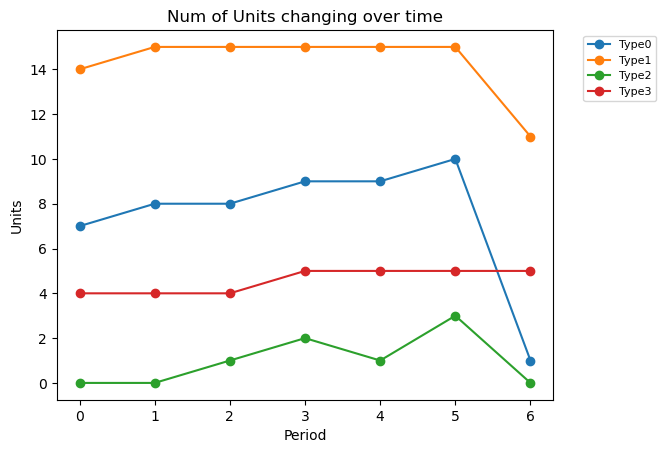

In [30]:
rows = ["Type" + str(t) for t in range(num_types)]
units = pd.DataFrame(columns=range(num_periods), index=rows, data=0.0)

for t in range(num_types):
    for p in range(num_periods):
        units.loc["Type"+str(t), p] = num_gen[t,p].x

display(units)

for idx, row in units.iterrows():
    y_values = row.values.astype(float)
    plt.plot(range(num_periods), y_values, marker='o', label=idx, linewidth=1.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title("Num of Units changing over time")
plt.xlabel("Period")
plt.ylabel("Units")
plt.show()


### 展示不同时间段开启机组的数量
每一行表示一种发电机组在不同时间段的开启数量，每一列则表示在该时间段下各种发电机组的开启数量。


In [32]:
starts = pd.DataFrame(columns=range(num_periods), index=rows, data=0.0)

for t in range(num_types):
    for p in range(num_periods):
        starts.loc["Type"+str(t), p] = int(num_start[t,p].x)
starts

,0,1,2,3,4,5,6
Type0,5.0,1.0,0.0,0.0,0.0,0.0,0.0
Type1,11.0,1.0,0.0,0.0,0.0,0.0,0.0
Type2,0.0,0.0,1.0,1.0,0.0,2.0,0.0
Type3,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### 展示不同时间段关闭机组的数量
每一行表示一种发电机组在不同时间段的关闭数量，每一列则表示在该时间段下各种发电机组的关闭数量。


In [34]:
ends = pd.DataFrame(columns=range(num_periods), index=rows, data=0.0)

for t in range(num_types):
    for p in range(num_periods):
        ends.loc["Type"+str(t), p] = int(num_stop[t,p].x)
ends

,0,1,2,3,4,5,6
Type0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
Type1,0.0,0.0,0.0,0.0,0.0,0.0,4.0
Type2,1.0,0.0,0.0,0.0,1.0,0.0,3.0
Type3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
